# CNN - Blood Cell Microscope Images Classification



In [ ]:

# Setup & download microscope dataset 

import warnings
warnings.filterwarnings("ignore")
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from medmnist import BloodMNIST

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

device = torch.device("mps" if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available() else "cpu")
print("Device:", device)

# test train dataset split
train_ds = BloodMNIST(split="train", download=True, size=224)
test_ds  = BloodMNIST(split="test",  download=True, size=224)
class_names = [train_ds.info["label"][str(i)] for i in range(8)]
print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")
print(f"Image shape: {np.array(train_ds[0][0]).shape} (RGB)")


Device: mps
Train: 11959 | Test: 3421
Image shape: (224, 224, 3) (RGB)


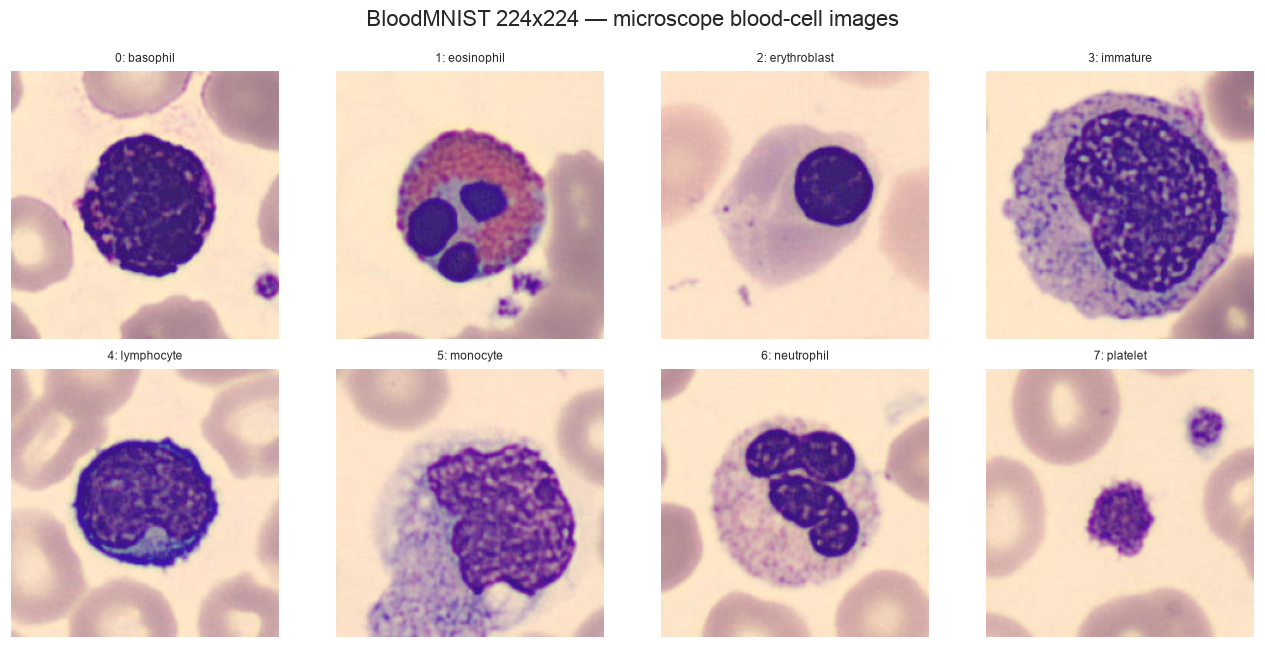

In [ ]:

# Visualize samples (224x224)

first_idx = {}
for i, (_, label) in enumerate(train_ds):
    c = int(label[0])
    if c not in first_idx:
        first_idx[c] = i
    if len(first_idx) == len(class_names):
        break

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, c in zip(axes.flat, sorted(first_idx)):
    img = np.array(train_ds[first_idx[c]][0])
    ax.imshow(img)
    ax.set_title(f"{c}: {class_names[c].split()[0]}", fontsize=8)
    ax.axis("off")
plt.suptitle("BloodMNIST 224x224 — microscope blood-cell images")
plt.tight_layout(); plt.show()

In [ ]:

# DataLoaders 
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5] * 3, std=[0.5] * 3),
])


class MedDataset(Dataset):
    def __init__(self, ds, transform=None):
        self.ds = ds
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, i):
        img, label = self.ds[i]
        if self.transform is not None:
            img = self.transform(img)
        return img, torch.tensor(int(label[0]), dtype=torch.long)


train_loader = DataLoader(MedDataset(train_ds, transform),
                          batch_size=64, shuffle=True)
test_loader  = DataLoader(MedDataset(test_ds, transform),
                          batch_size=64, shuffle=False)


class BloodCNN(nn.Module):
    "3 conv blocks + global average pooling "
    def __init__(self, num_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.fc(x.flatten(1))


model = BloodCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print(model)



BloodCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (fc): Linear(in_features=128, out_features=8, bias=True)
)
Trainable params: 94,280


In [5]:

# Training loop 
# 100 epochs

def train_one_epoch(loader, model, criterion, optimizer, device):
    model.train()
    total = correct = 0
    loss_sum = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += yb.size(0)
    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate(loader, model, device):
    model.eval()
    total = correct = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        correct += (model(xb).argmax(1) == yb).sum().item()
        total += yb.size(0)
    return correct / total


EPOCHS = 100
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(train_loader, model, criterion,
                                      optimizer, device)
    te_acc = evaluate(test_loader, model, device)
    print(f"Epoch {epoch:2d} | loss {tr_loss:.4f} | train acc {tr_acc:.4f} | "
          f"test acc {te_acc:.4f} | {time.time()-t0:.0f}s")


Epoch  1 | loss 1.1375 | train acc 0.5822 | test acc 0.7010 | 49s
Epoch  2 | loss 0.7209 | train acc 0.7358 | test acc 0.7682 | 48s
Epoch  3 | loss 0.6241 | train acc 0.7772 | test acc 0.8068 | 47s
Epoch  4 | loss 0.5362 | train acc 0.8153 | test acc 0.8354 | 47s
Epoch  5 | loss 0.4765 | train acc 0.8352 | test acc 0.8696 | 47s
Epoch  6 | loss 0.4315 | train acc 0.8573 | test acc 0.8784 | 46s
Epoch  7 | loss 0.3992 | train acc 0.8686 | test acc 0.8693 | 47s
Epoch  8 | loss 0.3588 | train acc 0.8828 | test acc 0.8693 | 45s
Epoch  9 | loss 0.3240 | train acc 0.8912 | test acc 0.8977 | 46s
Epoch 10 | loss 0.2938 | train acc 0.9062 | test acc 0.9135 | 47s
Epoch 11 | loss 0.2876 | train acc 0.9057 | test acc 0.9179 | 46s
Epoch 12 | loss 0.2699 | train acc 0.9114 | test acc 0.9243 | 45s
Epoch 13 | loss 0.2616 | train acc 0.9128 | test acc 0.8699 | 44s
Epoch 14 | loss 0.2479 | train acc 0.9160 | test acc 0.9193 | 44s
Epoch 15 | loss 0.2317 | train acc 0.9257 | test acc 0.9243 | 44s
Epoch 16 |

Test accuracy: 0.9775
                                                                     precision    recall  f1-score   support

                                                           basophil     0.9641    0.9918    0.9778       244
                                                         eosinophil     0.9984    1.0000    0.9992       624
                                                       erythroblast     0.9838    0.9775    0.9806       311
immature granulocytes(myelocytes, metamyelocytes and promyelocytes)     0.9832    0.9102    0.9453       579
                                                         lymphocyte     0.9603    0.9959    0.9778       243
                                                           monocyte     0.9582    0.9683    0.9632       284
                                                         neutrophil     0.9551    0.9910    0.9727       666
                                                           platelet     1.0000    1.0000    1.0000       

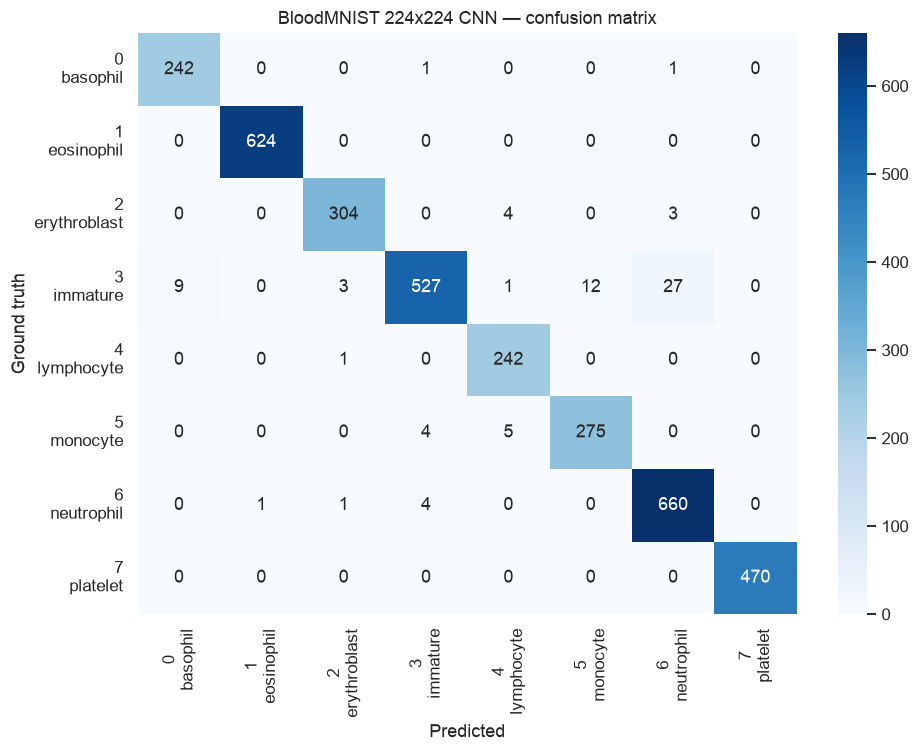

In [7]:

# Evaluation — accuracy, classification report, confusion matrix

from sklearn.metrics import confusion_matrix, classification_report


@torch.no_grad()
def predict_all(loader, model, device):
    model.eval()
    ys, preds = [], []
    for xb, yb in loader:
        preds.append(model(xb.to(device)).argmax(1).cpu())
        ys.append(yb)
    return torch.cat(ys).numpy(), torch.cat(preds).numpy()


y_true, y_pred = predict_all(test_loader, model, device)
acc = (y_true == y_pred).mean()
print(f"Test accuracy: {acc:.4f}")
print(classification_report(y_true, y_pred, target_names=class_names,
                            digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[f"{i}\n{n.split()[0]}" for i, n in enumerate(class_names)],
            yticklabels=[f"{i}\n{n.split()[0]}" for i, n in enumerate(class_names)])
plt.title("BloodMNIST 224x224 CNN — confusion matrix")
plt.xlabel("Predicted"); plt.ylabel("Ground truth")
plt.tight_layout(); plt.show()


